# class imbalance
modified class-removal label-kmeans experiment (celeba + chestxray14) to test class-imbalance


- kmeans is done on label co-occurrence
- class-removal `kmeans` targets are label-cluster ids

In [13]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.cluster import KMeans

CURRENT = Path.cwd().resolve()
REPO_ROOT = None
for candidate in [CURRENT, *CURRENT.parents]:
    if (candidate / "Datasets").exists() and (candidate / "Scripts").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root containing Datasets/ and Scripts/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from Datasets.unified_dataset_loader import make_default_loader

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
print("repo root:", REPO_ROOT)

repo root: C:\Users\ilyad\OneDrive\Documents\stat\Project 2\application\Group07_Improving_Metrics


In [14]:
def _dataset_class_names(dataset):
    # for multi-label datasets prefer explicit label-name fields first.
    if hasattr(dataset, "attr_names") and dataset.attr_names is not None:
        names = [str(name) for name in list(dataset.attr_names)]
        if names:
            return names
    if hasattr(dataset, "finding_classes") and dataset.finding_classes is not None:
        names = [str(name) for name in list(dataset.finding_classes)]
        if names:
            return names
    if hasattr(dataset, "classes") and dataset.classes is not None:
        return [str(name) for name in list(dataset.classes)]
    return []


def load_sample_bundle(dataset_name, data_root, image_size=64, sample_count=1200, download=False):
    loader = make_default_loader(
        dataset_name=dataset_name,
        data_root=str(data_root),
        image_size=image_size,
    )
    dataset = loader.get_dataset(train=False, download=download)
    class_names = _dataset_class_names(dataset)

    dataloader = DataLoader(
        dataset,
        batch_size=min(128, sample_count),
        shuffle=True,
        num_workers=0,
    )

    image_batches = []
    target_batches = []
    total = 0
    for images, targets in dataloader:
        image_batches.append(images)
        target_batches.append(torch.as_tensor(targets))
        total += int(images.shape[0])
        if total >= sample_count:
            break

    images = torch.cat(image_batches, dim=0)[:sample_count]
    targets = torch.cat(target_batches, dim=0)[:sample_count]
    return {
        "images": images,
        "targets": targets,
        "class_names": class_names,
    }


def targets_to_binary_matrix(targets, class_names):
    target_np = targets.detach().cpu().numpy()
    if target_np.ndim == 1:
        n_classes = int(target_np.max()) + 1 if target_np.size else 1
        n_classes = max(n_classes, len(class_names), 1)
        matrix = np.zeros((target_np.shape[0], n_classes), dtype=np.uint8)
        if target_np.size:
            matrix[np.arange(target_np.shape[0]), target_np.astype(int)] = 1
    else:
        matrix = (target_np > 0).astype(np.uint8)

    n_cols = int(matrix.shape[1])
    names = [str(name) for name in list(class_names)]
    if len(names) > n_cols:
        names = names[:n_cols]
    elif len(names) < n_cols:
        names = names + [f"class_{idx}" for idx in range(len(names), n_cols)]

    supports = matrix.sum(axis=0)
    return matrix, names, supports


def label_cooccurrence_features(label_matrix):
    # each label is a point, represented by its co-occurrence profile with all labels.
    co_counts = label_matrix.T @ label_matrix
    supports = label_matrix.sum(axis=0).astype(np.float64)
    supports[supports <= 0] = 1.0
    features = co_counts.astype(np.float64) / supports[:, None]
    np.fill_diagonal(features, 1.0)
    return features


def run_label_kmeans(label_matrix, class_names, k=8, seed=10):
    features = label_cooccurrence_features(label_matrix)
    if int(k) > int(features.shape[0]):
        raise ValueError(f"k={k} cannot be greater than number of labels={features.shape[0]}")
    kmeans = KMeans(n_clusters=int(k), random_state=int(seed), n_init=10)
    label_cluster_ids = kmeans.fit_predict(features)
    return {
        "features": features,
        "label_cluster_ids": label_cluster_ids,
        "class_names": class_names,
    }


def summarize_label_clusters(class_names, supports, label_cluster_ids):
    frame = pd.DataFrame(
        {
            "label": class_names,
            "support": supports.astype(int),
            "cluster": label_cluster_ids.astype(int),
        }
    )
    return frame.sort_values(["cluster", "support"], ascending=[True, False]).reset_index(drop=True)


def plot_label_cluster_support(summary_df, title):
    plt.figure(figsize=(10, 4.5))
    sns.barplot(data=summary_df, x="cluster", y="support", estimator=np.sum, errorbar=None)
    plt.title(title)
    plt.xlabel("label-cluster id")
    plt.ylabel("total positive label count")
    plt.tight_layout()
    plt.show()


def plot_cooccurrence_heatmap(features, label_cluster_ids, class_names, title):
    # reorder by cluster id so blocks are easier to read.
    order = np.argsort(label_cluster_ids)
    ordered = features[order][:, order]
    ordered_names = [class_names[idx] for idx in order]

    plt.figure(figsize=(9, 7))
    sns.heatmap(ordered, cmap="mako", vmin=0.0, vmax=1.0, xticklabels=ordered_names, yticklabels=ordered_names)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# had to change kmeans function since it gave error 
# label_cluster_ids = kmeans.fit_predict(features)
#     89 return {
# 646 config = get_config().split()
#    647 if config[0] == b"OpenBLAS":
#    648     return config[1].decode("utf-8")
#AttributeError: 'NoneType' object has no attribute 'split'

def run_label_kmeans(label_matrix, class_names, k=8, seed=10):
    features = label_cooccurrence_features(label_matrix)
    
    if int(k) > int(features.shape[0]):
        raise ValueError(f"k={k} cannot be greater than labels={features.shape[0]}")

    print(f"Bypassing broken KMeans. Running manual centroid clustering for k={k}...")
    
    rng = np.random.default_rng(seed)
    centroids = features[rng.choice(features.shape[0], size=int(k), replace=False)]
    
    for _ in range(10):  # 10 is recommened
        distances = np.linalg.norm(features[:, np.newaxis] - centroids, axis=2)
        label_cluster_ids = np.argmin(distances, axis=1)
        for i in range(int(k)):
            mask = (label_cluster_ids == i)
            if np.any(mask):
                centroids[i] = features[mask].mean(axis=0)

    return {
        "features": features,
        "label_cluster_ids": label_cluster_ids,
        "class_names": class_names,
    }

Bypassing broken KMeans. Running manual centroid clustering for k=12...


,label,support,cluster
0,Big_Nose,276,0
1,Bags_Under_Eyes,266,0
2,Narrow_Eyes,201,0
3,Receding_Hairline,113,0
4,Wavy_Hair,420,1
5,Wearing_Lipstick,612,2
6,Heavy_Makeup,469,2
7,5_o_Clock_Shadow,124,3
8,Goatee,65,3
9,Sideburns,57,3


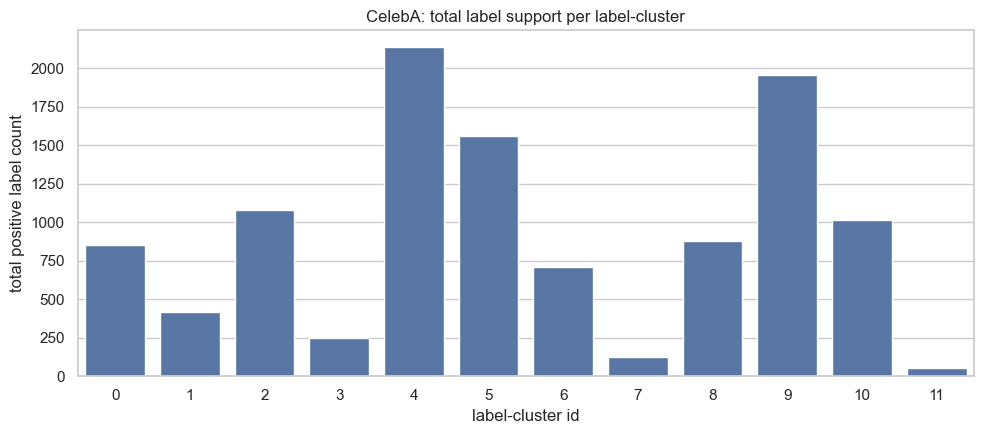

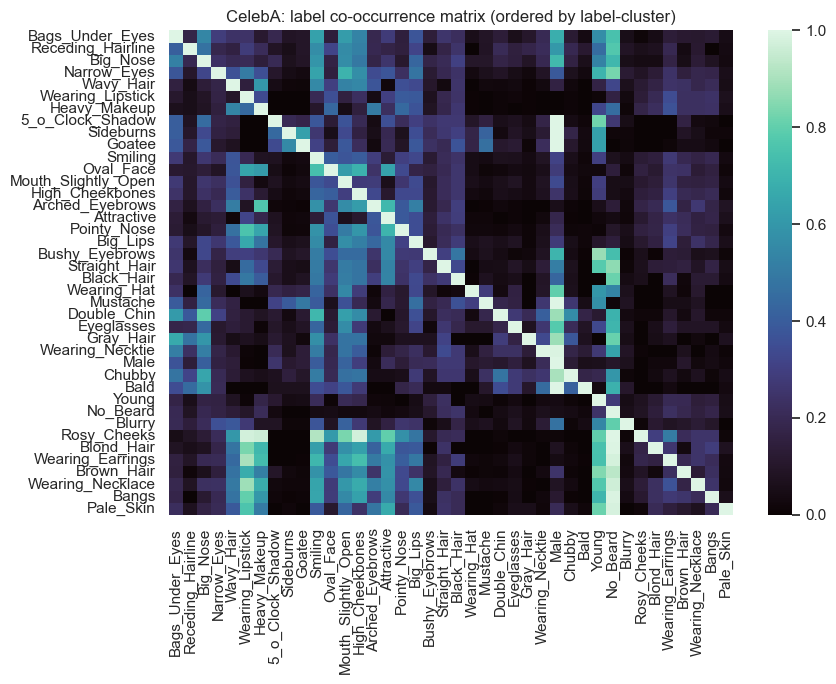

For PERTURB_IMBALANCED_CLASS_STRATEGY='kmeans', target 1 skewed labels:
Wavy_Hair


In [19]:
# celeba: label co-occurrence kmeans
celeba_root = REPO_ROOT / "data" / "CelebA"
celeba_bundle = load_sample_bundle(
    dataset_name="celeba",
    data_root=celeba_root,
    image_size=64,
    sample_count=1200,
    download=False,
)

celeba_matrix, celeba_names, celeba_supports = targets_to_binary_matrix(
    celeba_bundle["targets"],
    celeba_bundle["class_names"],
)
celeba_kmeans = run_label_kmeans(celeba_matrix, celeba_names, k=12, seed=10)
celeba_summary = summarize_label_clusters(
    class_names=celeba_names,
    supports=celeba_supports,
    label_cluster_ids=celeba_kmeans["label_cluster_ids"],
)

display(celeba_summary)
plot_label_cluster_support(celeba_summary, title="CelebA: total label support per label-cluster")
plot_cooccurrence_heatmap(
    features=celeba_kmeans["features"],
    label_cluster_ids=celeba_kmeans["label_cluster_ids"],
    class_names=celeba_names,
    title="CelebA: label co-occurrence matrix (ordered by label-cluster)",
)

# example: this is what a kmeans target means in pipeline config.
imbalance_cluster = 1
skewed_labels = celeba_summary.loc[celeba_summary["cluster"] == imbalance_cluster, "label"].tolist()
print("For PERTURB_IMBALANCED_CLASS_STRATEGY='kmeans', target", imbalance_cluster, "skewed labels:")
print(", ".join(skewed_labels))

In [21]:
sys.path.append(str(REPO_ROOT))

from Perturbation.class_imbalance import apply_class_imbalance


test_config = {
    "strategy": "label",          
    "targets_raw": "0",           # The first class
    "min_kept": 10,
    "seed": 42,
    "label_threshold": 0.5,
}

balance_levels = [0.0, 0.5, 1.0]

print(f"Original samples: {len(celeba_bundle['images'])}\n")

for b in balance_levels:
    test_config["balance"] = b
    
    filtered_images, details = apply_class_imbalance(
        fake_samples=celeba_bundle["images"],
        config=test_config,
        real_samples=celeba_bundle["images"], 
        reference_targets=celeba_bundle["targets"],
        reference_class_names=celeba_bundle["class_names"],
        dataset_name="celeba_test"
    )
    
    removed = details['removed_count']
    kept = details['kept_count']
    print(f"--- Balance: {b} ---")
    print(f"Images Removed: {removed}")
    print(f"Images Kept: {kept}")
    print(f"Target Class Indices Dropped: {details['drop_classes']}\n")

Original samples: 1200

--- Balance: 0.0 ---
Images Removed: 0
Images Kept: 1200
Target Class Indices Dropped: [0]

--- Balance: 0.5 ---
Images Removed: 184
Images Kept: 1016
Target Class Indices Dropped: [0]

--- Balance: 1.0 ---
Images Removed: 392
Images Kept: 808
Target Class Indices Dropped: [0]



In [25]:
# testing balance for more than one classes
sys.path.append(str(REPO_ROOT))

from Perturbation.class_imbalance import apply_class_imbalance


test_config = {
    "strategy": "label",          
    "targets_raw": "0,1",           # first and second class
    "min_kept": 10,
    "seed": 42,
    "label_threshold": 0.5,
}

balance_levels = [[0,0], [0.1,0.9]]

for b in balance_levels:
    test_config["balance"] = b
    
    filtered_images, details = apply_class_imbalance(
        fake_samples=celeba_bundle["images"],
        config=test_config,
        real_samples=celeba_bundle["images"], 
        reference_targets=celeba_bundle["targets"],
        reference_class_names=celeba_bundle["class_names"],
        dataset_name="celeba_test"
    )
    
    print(f"Balance {b}")
    print(f"Total Removed: {details['removed_count']}")
    print(f"Total Kept:    {details['kept_count']}")
    print("\n--- Per Class Count ---")

    for class_idx, count in details['predicted_positive_counts'].items():
        name = celeba_bundle['class_names'][int(class_idx)]
        idx_in_targets = details['drop_classes'].index(int(class_idx))
        target_balance = b[idx_in_targets]
        
        expected_to_drop = int(count * target_balance)
        
        print(f"Class {class_idx} ({name}):")
        print(f"  - Found in dataset: {count} images")
        print(f"  - Targeted for removal: ~{expected_to_drop} images ({target_balance*100}%)")
    
    print("\n")

Balance [0, 0]
Total Removed: 0
Total Kept:    1200

--- Per Class Count ---
Class 0 (5_o_Clock_Shadow):
  - Found in dataset: 392 images
  - Targeted for removal: ~0 images (0%)
Class 1 (Arched_Eyebrows):
  - Found in dataset: 536 images
  - Targeted for removal: ~0 images (0%)


Balance [0.1, 0.9]
Total Removed: 509
Total Kept:    691

--- Per Class Count ---
Class 0 (5_o_Clock_Shadow):
  - Found in dataset: 392 images
  - Targeted for removal: ~39 images (10.0%)
Class 1 (Arched_Eyebrows):
  - Found in dataset: 536 images
  - Targeted for removal: ~482 images (90.0%)




,label,support,cluster
0,Edema,346,0
1,Pneumonia,236,0
2,Effusion,1843,1
3,Atelectasis,1283,1
4,Consolidation,690,1
5,Mass,667,1
6,Pleural_Thickening,455,1
7,Cardiomegaly,428,1
8,Pneumothorax,1025,2
9,Emphysema,392,2


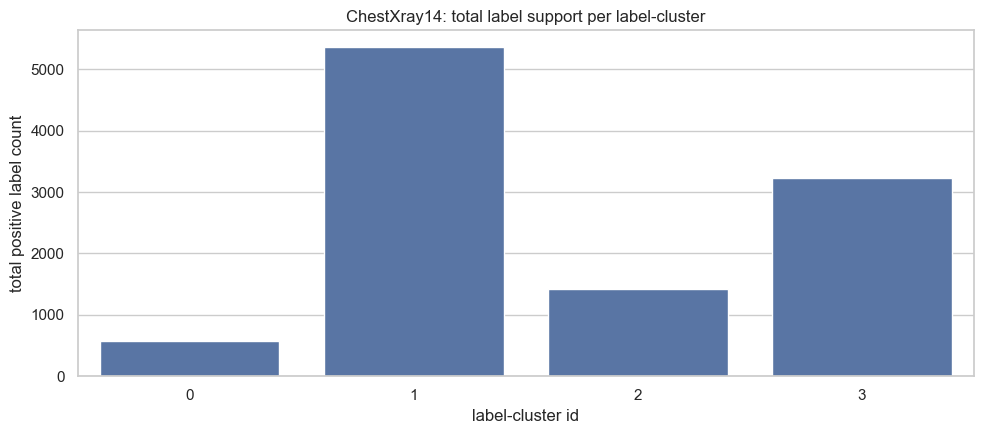

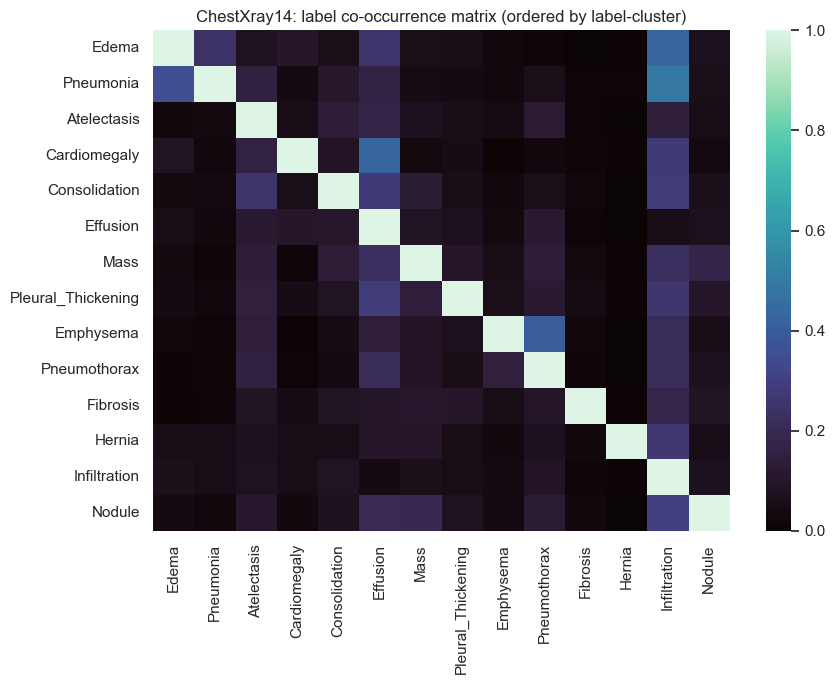

For PERTURB_CLASS_REMOVAL_STRATEGY='kmeans', target 0 drops labels:
Edema, Pneumonia


In [ ]:
# chestxray14: label co-occurrence kmeans
chest_root = REPO_ROOT / "data" / "ChestXray14"
chest_bundle = load_sample_bundle(
    dataset_name="chestxray14",
    data_root=chest_root,
    image_size=64,
    sample_count=10000,
    download=False,
)

chest_matrix, chest_names, chest_supports = targets_to_binary_matrix(
    chest_bundle["targets"],
    chest_bundle["class_names"],
)
chest_kmeans = run_label_kmeans(chest_matrix, chest_names, k=4, seed=42)
chest_summary = summarize_label_clusters(
    class_names=chest_names,
    supports=chest_supports,
    label_cluster_ids=chest_kmeans["label_cluster_ids"],
)

display(chest_summary)
plot_label_cluster_support(chest_summary, title="ChestXray14: total label support per label-cluster")
plot_cooccurrence_heatmap(
    features=chest_kmeans["features"],
    label_cluster_ids=chest_kmeans["label_cluster_ids"],
    class_names=chest_names,
    title="ChestXray14: label co-occurrence matrix (ordered by label-cluster)",
)

imbalance_cluster = 0
skewed_labels = chest_summary.loc[chest_summary["cluster"] == imbalance_cluster, "label"].tolist()
print("For PERTURB_IMBALANCED_CLASS_STRATEGY='kmeans', target", imbalance_cluster, "skewed labels:")
print(", ".join(skewed_labels))

## note

- kmeans target ids in pipeline (`PERTURB_CLASS_REMOVAL_TARGETS`) are **label-cluster ids**.
- this notebook helps inspect which labels each cluster id contains before dropping.